# Multi-Class Prediction of Obesity Risk

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e2/train.csv
/kaggle/input/competitions/playground-series-s4e2/test.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(20758, 18)
(13840, 17)


In [5]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
train.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [7]:
df=pd.concat([train,test]) 

## EDA

In [8]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34598 entries, 0 to 13839
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              34598 non-null  int64  
 1   Gender                          34598 non-null  object 
 2   Age                             34598 non-null  float64
 3   Height                          34598 non-null  float64
 4   Weight                          34598 non-null  float64
 5   family_history_with_overweight  34598 non-null  object 
 6   FAVC                            34598 non-null  object 
 7   FCVC                            34598 non-null  float64
 8   NCP                             34598 non-null  float64
 9   CAEC                            34598 non-null  object 
 10  SMOKE                           34598 non-null  object 
 11  CH2O                            34598 non-null  float64
 12  SCC                             34598

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,34598.0,17298.500000,9987.726643,0.00,8649.250000,17298.500000,25947.750000,34597.000000
Age,34598.0,23.886181,5.733207,14.00,20.000000,22.851747,26.000000,61.000000
Height,34598.0,1.699721,0.087895,1.45,1.631856,1.700000,1.761773,1.980000
Weight,34598.0,87.686451,26.273493,39.00,66.000000,84.000000,111.539494,165.057269
FCVC,34598.0,2.444704,0.532568,1.00,2.000000,2.392179,3.000000,3.000000
NCP,34598.0,2.757043,0.707610,1.00,3.000000,3.000000,3.000000,4.000000
CH2O,34598.0,2.030469,0.609566,1.00,1.784710,2.000000,2.550570,3.000000
FAF,34598.0,0.978861,0.839122,0.00,0.006892,1.000000,1.583832,3.000000
TUE,34598.0,0.614467,0.604475,0.00,0.000000,0.555591,1.000000,2.000000


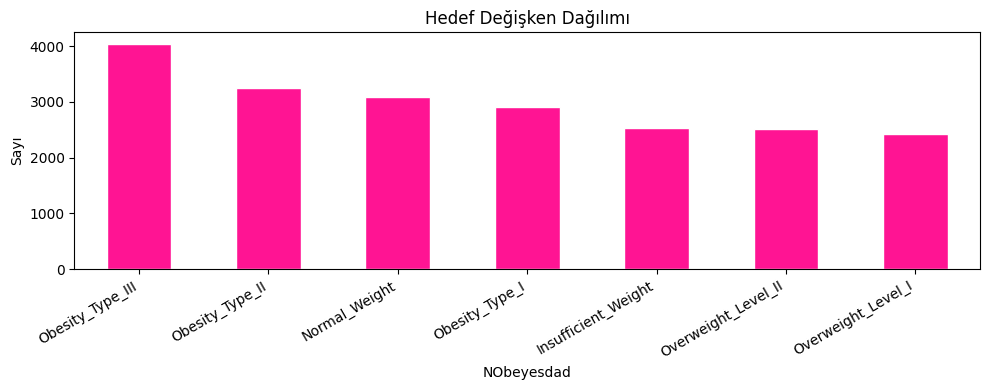

In [11]:
#NObeyesdad Distribution
plt.figure(figsize=(10, 4))
train['NObeyesdad'].value_counts().plot(kind='bar', color='DeepPink', edgecolor='white')
plt.title('Hedef Değişken Dağılımı')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

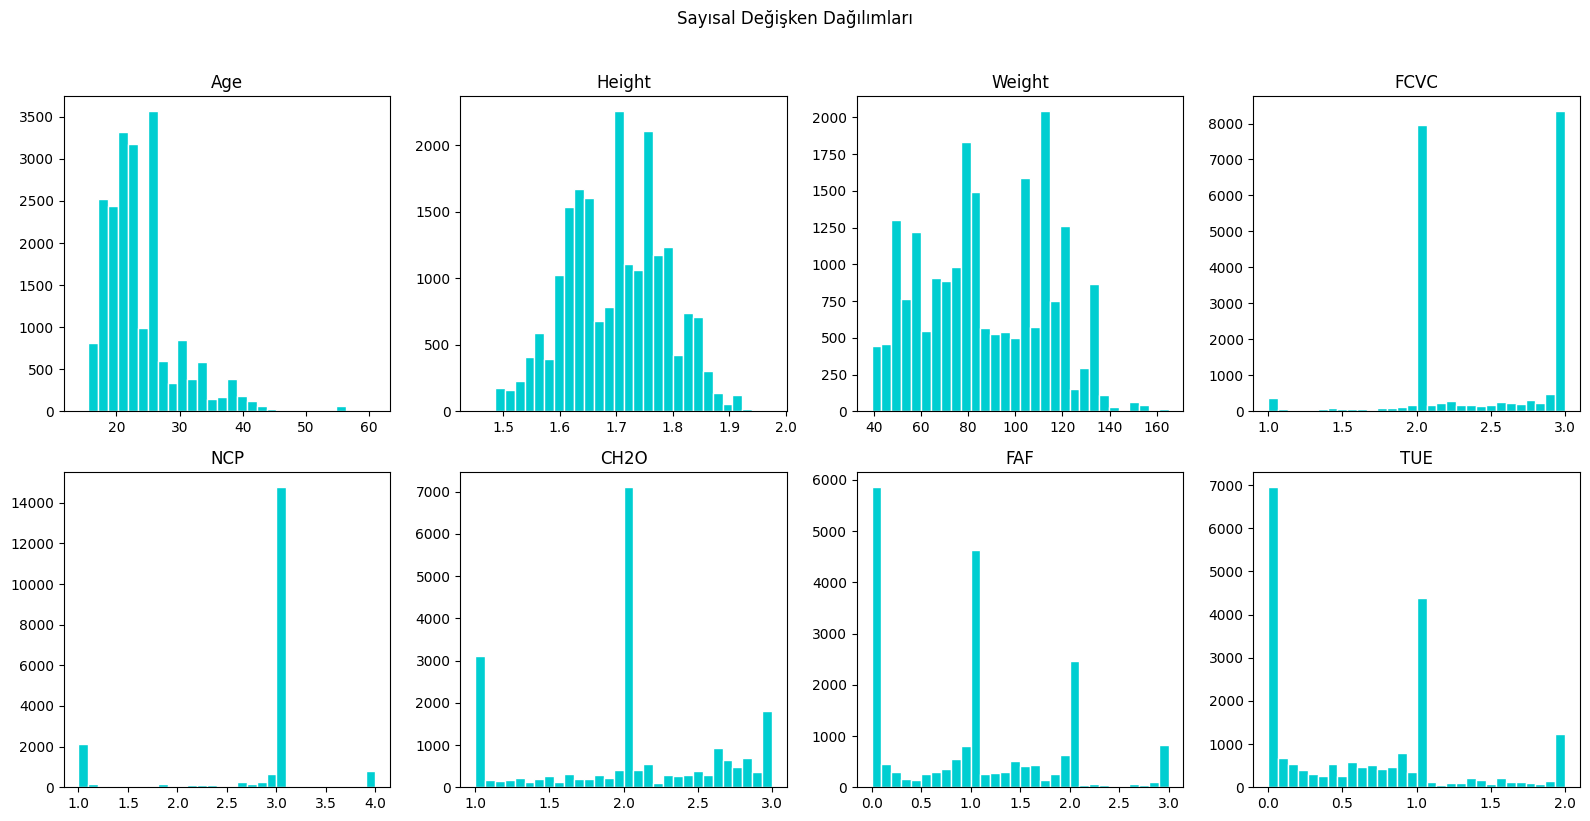

In [12]:
# Numeric cols
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    plt.hist(train[col], bins=30, color='DarkTurquoise', edgecolor='white')
    plt.title(col)
plt.suptitle('Sayısal Değişken Dağılımları', y=1.02)
plt.tight_layout()
plt.show()

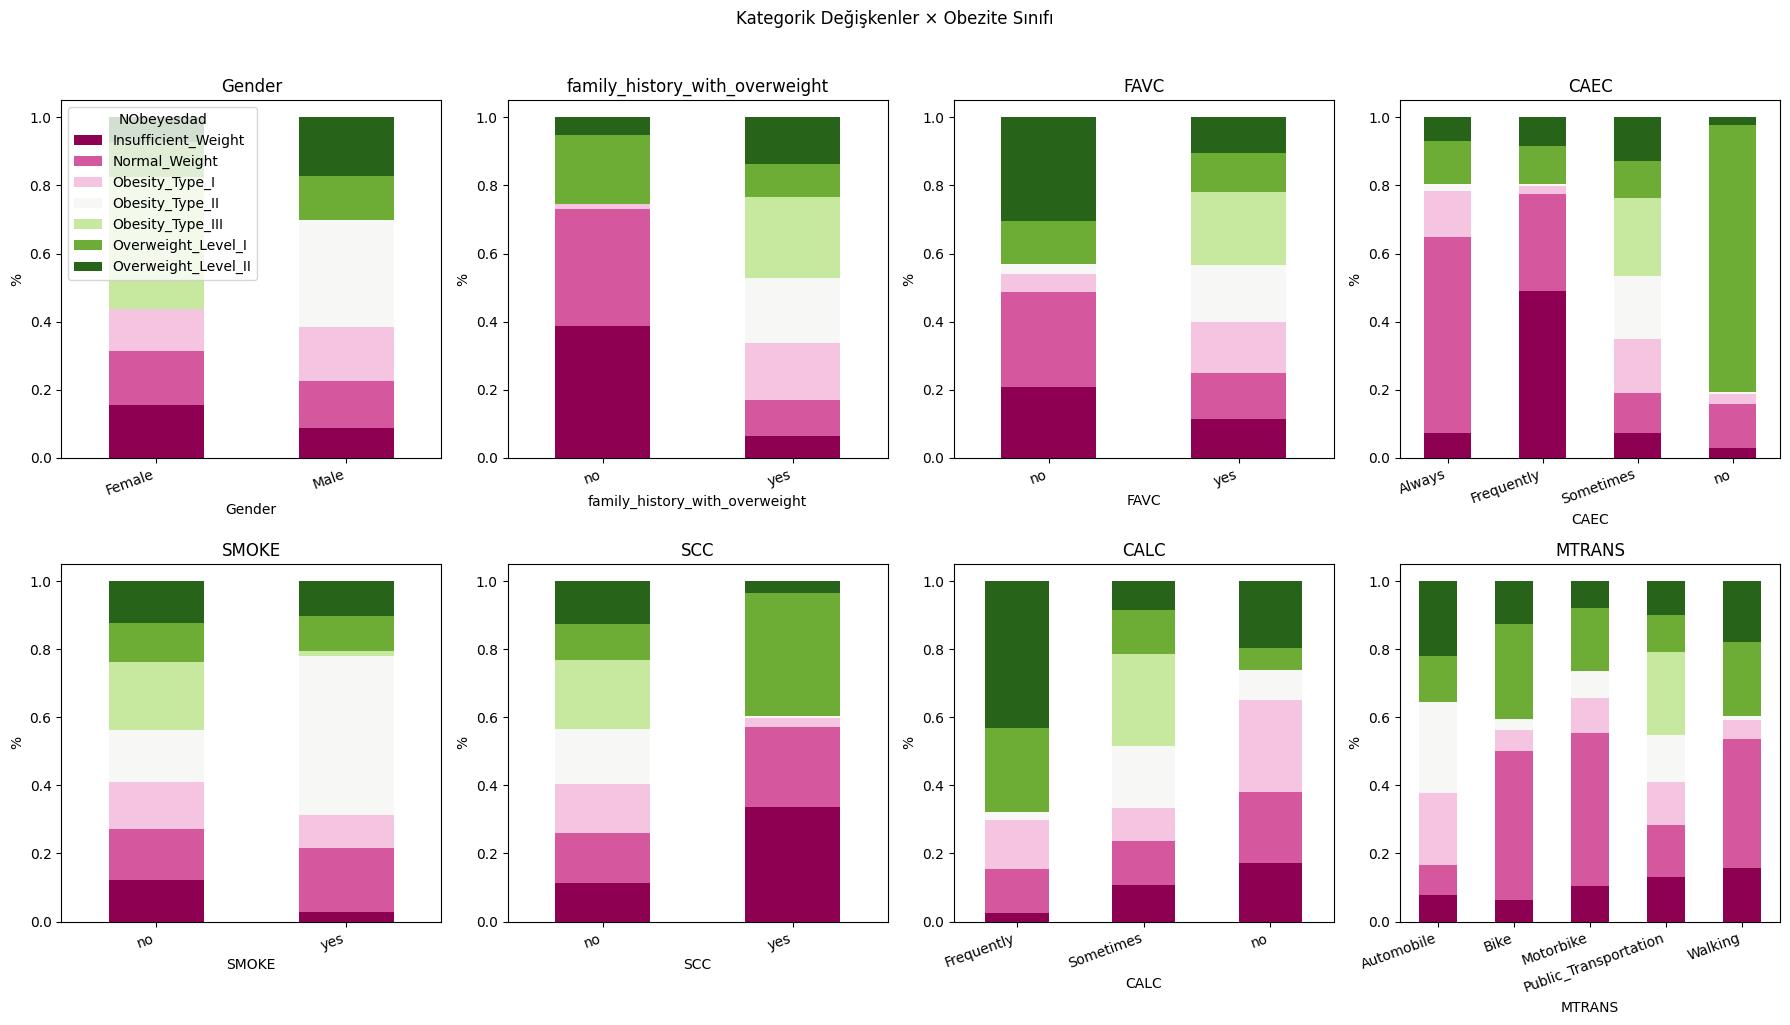

In [13]:
# Categorical Cols
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

plt.figure(figsize=(18, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 4, i)
    pd.crosstab(train[col], train['NObeyesdad'], normalize='index').plot(
        kind='bar', stacked=True, ax=plt.gca(), legend=(i == 1), colormap='PiYG'
    )
    plt.title(col)
    plt.xticks(rotation=20, ha='right')
    plt.ylabel('%')
plt.suptitle('Kategorik Değişkenler × Obezite Sınıfı', y=1.02)
plt.tight_layout()
plt.show()

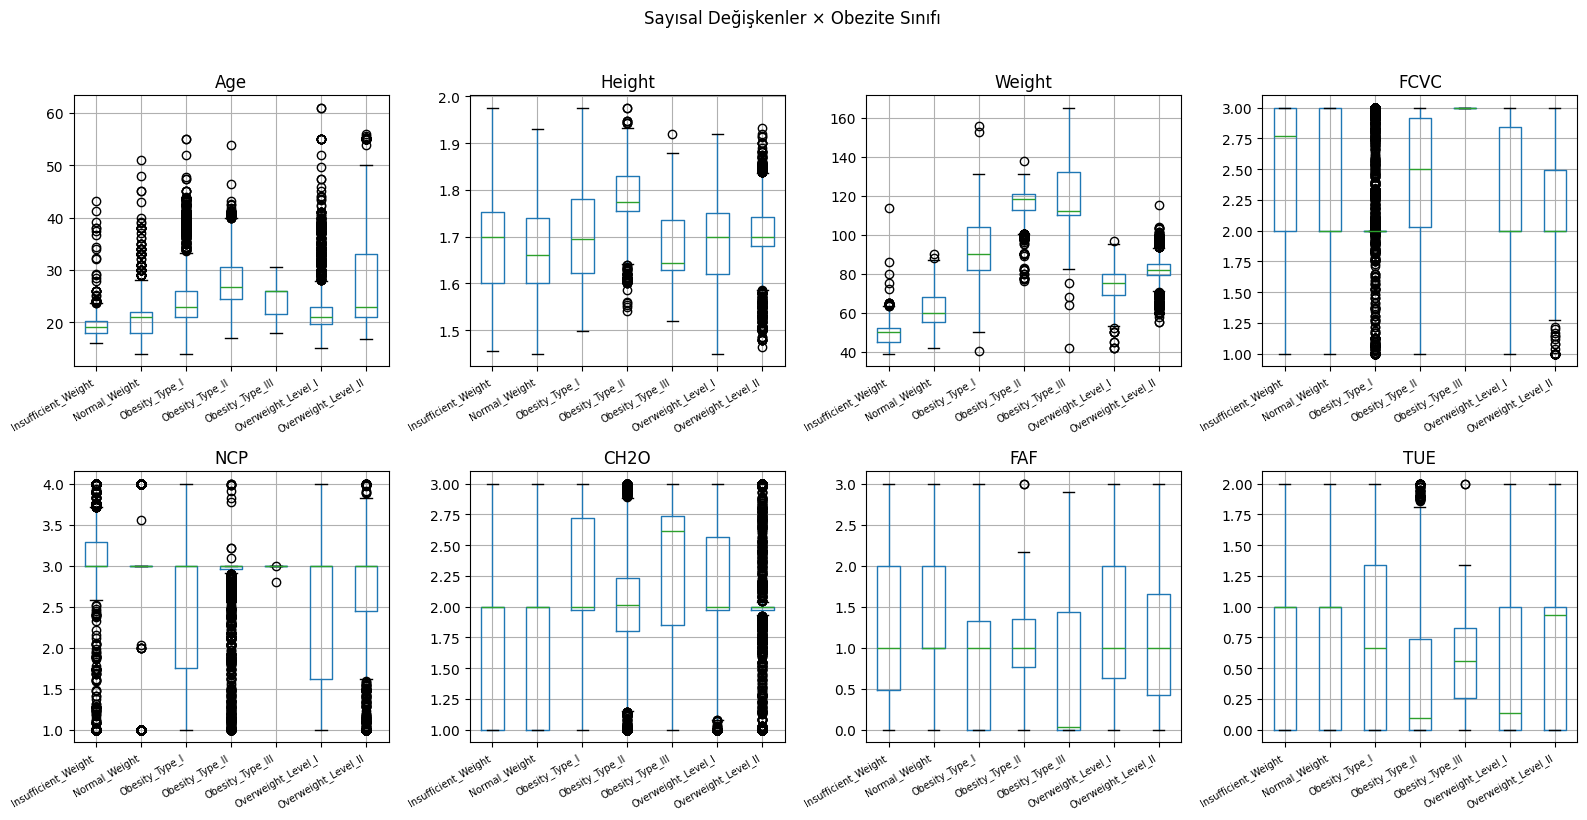

In [14]:
#Boxplot 
plt.figure(figsize=(16, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 4, i)
    train.boxplot(column=col, by='NObeyesdad', ax=plt.gca())
    plt.title(col)
    plt.suptitle('')
    plt.xlabel('')
    plt.xticks(rotation=30, ha='right', fontsize=7)
plt.suptitle('Sayısal Değişkenler × Obezite Sınıfı', y=1.02)
plt.tight_layout()
plt.show()

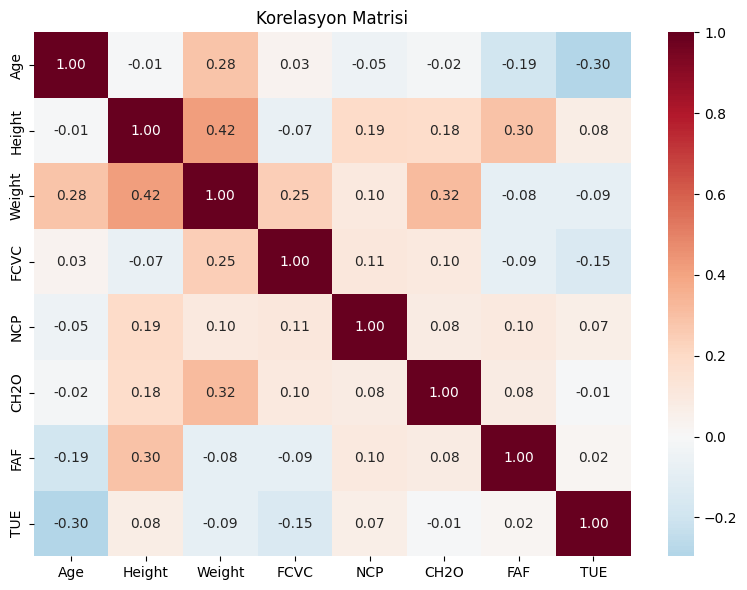

In [15]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## Feature Engineering

In [16]:
# BMI  Weight / Height**2
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [17]:
# CH2O ile Weight 0.32 korelasyon
df['Diet_Score'] = df['CH2O'] + df['FCVC']

In [18]:
# Weight / Height Rate
df['Weight_Height_Ratio'] = df['Weight'] / df['Height']

In [19]:
# Categorical cols  Binary Encoding 
df['Gender'] = (df['Gender'] == 'Male').astype(int)
df['family_history_with_overweight'] = (df['family_history_with_overweight'] == 'yes').astype(int)
df['FAVC']  = (df['FAVC']  == 'yes').astype(int)
df['SMOKE'] = (df['SMOKE'] == 'yes').astype(int)
df['SCC']   = (df['SCC']   == 'yes').astype(int)

In [20]:
# Ordinal Encoding 
caec_map  = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_map  = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
mtrans_map = {'Walking': 0, 'Bike': 1, 'Public_Transportation': 2, 'Motorbike': 3, 'Automobile': 4}

df['CAEC']   = df['CAEC'].map(caec_map)
df['CALC']   = df['CALC'].map(calc_map)
df['MTRANS'] = df['MTRANS'].map(mtrans_map)

In [21]:
# NObeyesdad Encoding 
target_map = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1,
    'Overweight_Level_I': 2,  'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,      'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
df['NObeyesdad'] = df['NObeyesdad'].map(target_map)

In [22]:
abs(df.corr(numeric_only=True))['NObeyesdad'].sort_values(ascending=False)

NObeyesdad                        1.000000
BMI                               0.961441
Weight_Height_Ratio               0.954534
Weight                            0.921250
family_history_with_overweight    0.522026
Diet_Score                        0.367314
CAEC                              0.364052
Age                               0.356211
CH2O                              0.273154
FCVC                              0.272933
FAF                               0.234745
FAVC                              0.215401
CALC                              0.189361
SCC                               0.184959
Height                            0.150141
TUE                               0.121009
Gender                            0.067699
MTRANS                            0.031141
NCP                               0.027227
id                                0.016240
SMOKE                             0.013501
Name: NObeyesdad, dtype: float64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34598 entries, 0 to 13839
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              34598 non-null  int64  
 1   Gender                          34598 non-null  int64  
 2   Age                             34598 non-null  float64
 3   Height                          34598 non-null  float64
 4   Weight                          34598 non-null  float64
 5   family_history_with_overweight  34598 non-null  int64  
 6   FAVC                            34598 non-null  int64  
 7   FCVC                            34598 non-null  float64
 8   NCP                             34598 non-null  float64
 9   CAEC                            34598 non-null  int64  
 10  SMOKE                           34598 non-null  int64  
 11  CH2O                            34598 non-null  float64
 12  SCC                             34598

## Train Test Split

In [24]:
train = df[df['NObeyesdad'].notna()]
test  = df[df['NObeyesdad'].isna()]

In [25]:
x = train.drop(['id', 'SMOKE', 'NCP', 'MTRANS','NObeyesdad'], axis=1)

y = train['NObeyesdad']

In [26]:
x_final_test = test.drop(['id', 'SMOKE', 'NCP', 'MTRANS','NObeyesdad'], axis=1)

## Model Training

In [27]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        XGBClassifier(eval_metric='mlogloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

results = algo_test(x, y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
LogisticRegression modeli eğitiliyor...
DecisionTreeClassifier modeli eğitiliyor...
RandomForestClassifier modeli eğitiliyor...
GradientBoostingClassifier modeli eğitiliyor...
KNeighborsClassifier modeli eğitiliyor...
AdaBoostClassifier modeli eğitiliyor...
XGBClassifier modeli eğitiliyor...
LGBMClassifier modeli eğitiliyor...
CatBoostClassifier modeli eğitiliyor...
Eğitim tamamlandı.

En başarılı model: XGBClassifier

Confusion Matrix:
[[481  37   4   2   0   0   0]
 [ 27 555  38   6   0   0   0]
 [  2  34 386  52  10   0   0]
 [  0   8  44 418  38   6   0]
 [  2   1  14  40 473  12   1]
 [  0   0   0   2  16 637   2]
 [  0   0   1   0   0   1 802]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93       524
         1.0       0.87      0.89      0.88       626
         2.0       0.79      0.80      0.80       484
         3.0       0.80      0

In [28]:
best_model= XGBClassifier(eval_metric='mlogloss', verbosity=0, random_state=42)
best_model.fit(x,y)

pred_final= best_model.predict(x_final_test)

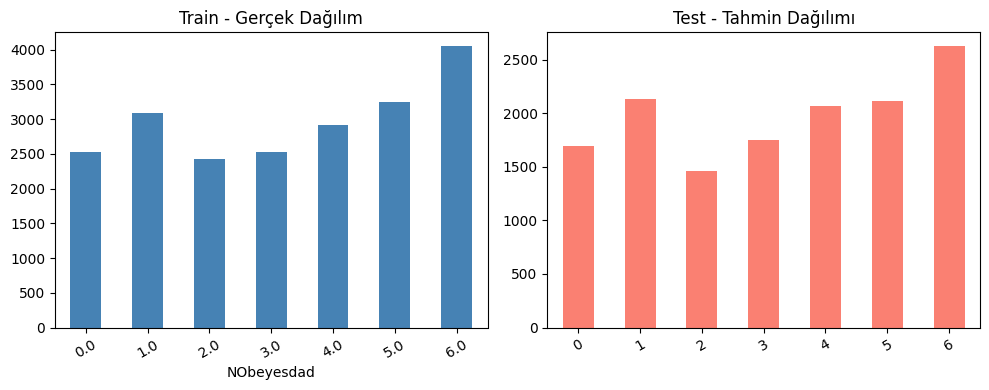

In [29]:
# Train and test prediction distribution 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
pd.Series(y).value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Train - Gerçek Dağılım')
plt.xticks(rotation=30)

plt.subplot(1, 2, 2)
pd.Series(pred_final).value_counts().sort_index().plot(kind='bar', color='salmon')
plt.title('Test - Tahmin Dağılımı')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [30]:
submission = pd.DataFrame({
    'id': test['id'],
    'NObeyesdad': pred_final
})

In [31]:
submission.head()

,id,NObeyesdad
0,20758,5
1,20759,2
2,20760,6
3,20761,4
4,20762,6


In [32]:
target_map = {
    0: 'Insufficient_Weight',
    1: 'Normal_Weight',
    2: 'Overweight_Level_I',
    3: 'Overweight_Level_II',
    4: 'Obesity_Type_I',
    5: 'Obesity_Type_II',
    6: 'Obesity_Type_III'
}

submission = pd.DataFrame({
    'id': test['id'],
    'NObeyesdad': pd.Series(pred_final).map(target_map).values
})

In [33]:
submission.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [34]:
submission.to_csv('submission.csv', index=False)